# 1. Setup

## 1.1 Config + Logger import

In [1]:
# ====== Imports ======
# Config
from config_loader import CONFIG

# Logger: LoggerManager + global configuration
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = (
    CONFIG.LOGGER_MANAGER_ENABLE_FILES_LOGS_MONITORING_ONLY_FOR_ONE_LOGGER
)
LoggerManager.enable_dynamic_config_update = CONFIG.LOGGER_MANAGER_ENABLE_DYNAMIC_CONFIG_UPDATE
LoggerManager.enable_unique_logger_identifier = CONFIG.LOGGER_MANAGER_ENABLE_UNIQUE_LOGGER_IDENTIFIER

LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=getattr(logger_colors, CONFIG.LOGGER_COLORS),
    path=CONFIG.LOGGER_PATH,
    # LogLevels
    decorator_log_level=getattr(LogLevels, CONFIG.LOGGER_DECORATOR_LOG_LEVEL),
    print_log_level=getattr(LogLevels, CONFIG.LOGGER_PRINT_LOG_LEVEL),
    file_log_level=getattr(LogLevels, CONFIG.LOGGER_FILE_LOG_LEVEL),
    # Loggers Output
    print_log=CONFIG.LOGGER_PRINT_LOG,
    write_to_file=CONFIG.LOGGER_WRITE_TO_FILE,
    # Monitoring
    display_monitoring=CONFIG.LOGGER_DISPLAY_MONITORING,
    files_monitoring=CONFIG.LOGGER_FILES_MONITORING,
    file_size_unit=CONFIG.LOGGER_FILE_SIZE_UNIT,
    disk_alert_threshold_percent=CONFIG.LOGGER_DISK_ALERT_THRESHOLD_PERCENT,
    log_files_size_alert_threshold_percent=CONFIG.LOGGER_FILES_SIZE_ALERT_THRESHOLD_PERCENT,
    max_log_file_size=CONFIG.LOGGER_MAX_LOG_FILE_SIZE,
    # Placement
    identifier_max_width=CONFIG.LOGGER_IDENTIFIER_MAX_WIDTH,
    filename_lineno_max_width=CONFIG.LOGGER_FILENAME_LINENO_MAX_WIDTH,
)

## 1.2 Importing Libraries

In [2]:
from arena import ShowArena
from geometry import OrientedPoint
from movement import GoToParams, MovementManager, TrajectoryParams, SpeedProfile

import matplotlib.pyplot as plt
import numpy as np
import time

# 2. Instanciate object

## 2.1 Loggers

In [3]:
logger_movement_manager = Logger(
    identifier="MvtManager",
    follow_logger_manager_rules=True,
)
logger_show_arena = Logger(
    identifier="ShowArena",
    follow_logger_manager_rules=True,
)
logger_grid_manager = Logger(
    identifier="GridManager",
    follow_logger_manager_rules=True,
)
logger_path_finder = Logger(
    identifier="PathFinder",
    follow_logger_manager_rules=True,
)
logger_trajectory_computer = Logger(
    identifier="TrajectoryComputer",
    follow_logger_manager_rules=True,
)

## 2.2 Arena

In [4]:
arena: ShowArena = ShowArena(
    logger=logger_show_arena,
    border_buffer=CONFIG.ARENA_BORDER_BUFFER,
    obstacle_buffer=CONFIG.ARENA_OBSTACLE_BUFFER,
    chunk_size=CONFIG.ARENA_CHUNK_SIZE,
    forbidden_cover_threshold=CONFIG.ARENA_FORBIDDEN_COVER_THRESHOLD,
    grid_manager_logger=logger_grid_manager,
)

18:51:25.167537 -> [   ShowArena   ] [  arena.py  :219]    INFO    | ShowArena initialized.


## 2.3 Movement Manager

In [5]:
movement_manager: MovementManager = MovementManager(
    logger=logger_movement_manager,
    path_finder_logger=logger_path_finder,
    trajectory_computer_logger=logger_trajectory_computer,
    arena_ptr=arena,
)

# 3. Tests

## 3.1 Create GoToParams

In [6]:
goto_params: GoToParams = GoToParams(
    trajectory_params=TrajectoryParams(
        speed_profile=SpeedProfile.from_dict(CONFIG.ROLLING_BASIS_HIGH_SPEED_PROFILE), 
        goal=OrientedPoint(44, 44), 
        resolution=1, 
        smooth_trajectory=True
    ), 
    acs_distance=20, 
    path_finder_recompute_distance=80, 
    timeout=-1.0, 
    is_mandatory=False, 
    goal_tolerance=0.1, 
    distance_to_goal_to_dont_recompute_path=20
)

## 3.2 Compute GoTo movement

In [7]:
movement_manager.compute_go_to(
    current_linear_speed=0.0,
    current_angular_speed=0.0,
    params=goto_params
)

18:51:25.192302 -> [   MvtManager  ] [movement_m..:166]  WARNING   | A movement is already in progress and a new one is requested.


## 3.3 Simulate GoTo movement and plot it

0/11
0/11
0/11
0/11
0/11
0/11
0/11
0/11
0/11
1/11
1/11
1/11
1/11
1/11
1/11
1/11
1/11
1/11
1/11
2/11
2/11
2/11
2/11
2/11
2/11
2/11
2/11
2/11
2/11
3/11
3/11
3/11
3/11
3/11
3/11
3/11
3/11
3/11
3/11
4/11
4/11
4/11
4/11
4/11
4/11
4/11
4/11
4/11
4/11
5/11
5/11
5/11
5/11
5/11
5/11
5/11
5/11
5/11
5/11
6/11
6/11
6/11
6/11
6/11
6/11
6/11
6/11
6/11
6/11
7/11
7/11
7/11
7/11
7/11
7/11
7/11
7/11
7/11
7/11
8/11
8/11
8/11
8/11
8/11
8/11
8/11
8/11
8/11
8/11
9/11
9/11
9/11
9/11
9/11
9/11
9/11
9/11
9/11
10/11
10/11
10/11
10/11
10/11
10/11
10/11
10/11
10/11
10/11
11/11


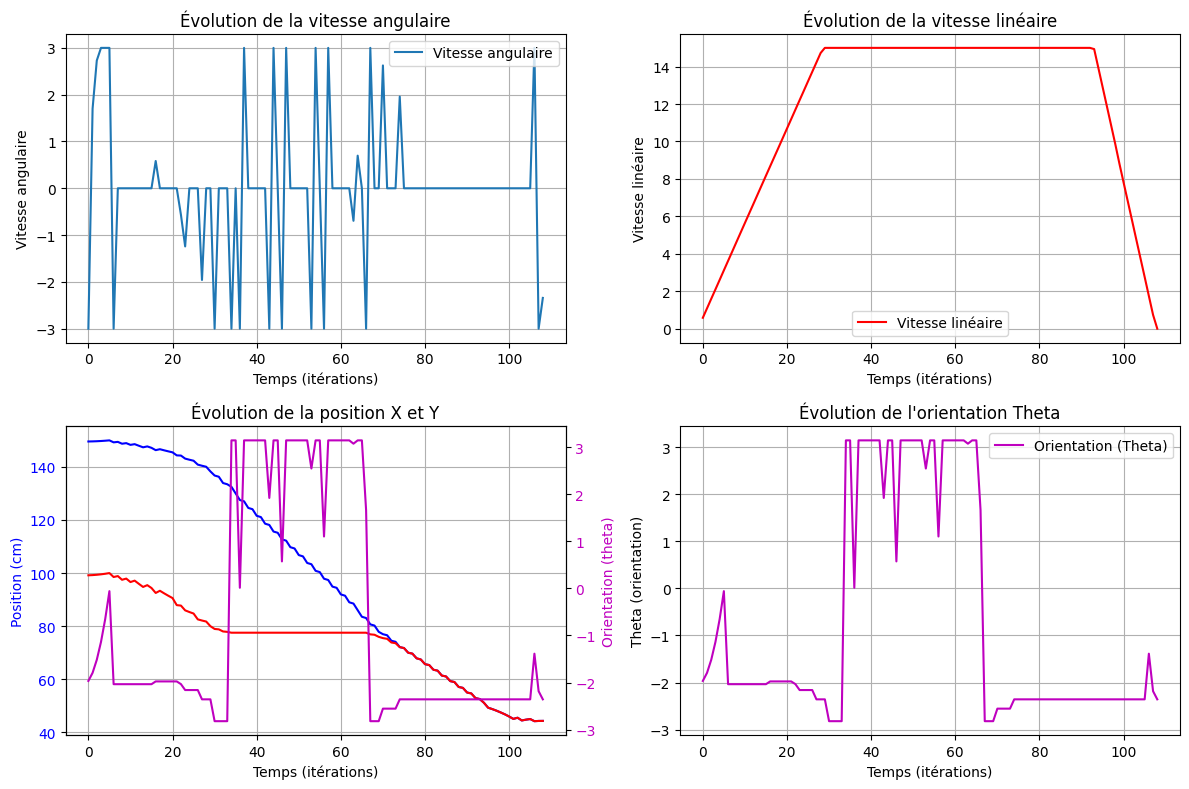

In [8]:
angular_speeds = []
linear_speeds = []
positions = []

start_time = time.time()
while start_time + movement_manager.trajectory_computer.total_duration > time.time():
    time.sleep(0.1)
    cmd = movement_manager.trajectory_computer.get_position_speed()

    positions.append(cmd.position)
    linear_speeds.append(cmd.linear_speed)
    angular_speeds.append(cmd.angular_speed)
    print(f"{int(time.time() - start_time)}/{int(movement_manager.trajectory_computer.total_duration)}")


x_positions = [pos.x for pos in positions]
y_positions = [pos.y for pos in positions]
theta_positions = [pos.theta for pos in positions]

# Création d'une figure avec plusieurs sous-graphiques
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Graphique des vitesses angulaires
axs[0, 0].plot(angular_speeds, label="Vitesse angulaire")
axs[0, 0].set_xlabel("Temps (itérations)")
axs[0, 0].set_ylabel("Vitesse angulaire")
axs[0, 0].set_title("Évolution de la vitesse angulaire")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Graphique des vitesses linéaires
axs[0, 1].plot(linear_speeds, label="Vitesse linéaire", color='r')
axs[0, 1].set_xlabel("Temps (itérations)")
axs[0, 1].set_ylabel("Vitesse linéaire")
axs[0, 1].set_title("Évolution de la vitesse linéaire")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Graphique des positions X-Y (Trajectoire) avec double axe Y
ax1 = axs[1, 0]  # Axe principal
ax2 = ax1.twinx()  # Deuxième axe Y

ax1.plot(x_positions, color='b', label="X (Position)")
ax1.plot(y_positions, color='r', label="Y (Position)")
ax1.set_ylabel("Position (cm)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2.plot(theta_positions, label="Orientation (Theta)", color='m')
ax2.set_ylabel("Orientation (theta)", color='m')
ax2.tick_params(axis='y', labelcolor='m')

ax1.set_xlabel("Temps (itérations)")
ax1.set_title("Évolution de la position X et Y")
ax1.grid(True)

# Graphique des angles Theta en fonction du temps
axs[1, 1].plot(theta_positions, label="Orientation (Theta)", color='m')
axs[1, 1].set_xlabel("Temps (itérations)")
axs[1, 1].set_ylabel("Theta (orientation)")
axs[1, 1].set_title("Évolution de l'orientation Theta")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Ajustement des espacements entre les sous-graphiques
plt.tight_layout()
plt.show()